<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/ICG_subcomplexes/HC_full_code_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Libraries

In [3]:
!pip install tslearn

In [4]:
!pip install -q pyclustering

In [5]:
!pip install kneed

In [6]:
# --- Librerías científicas y de manejo de datos ---
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as signal
from scipy.signal import butter, filtfilt, savgol_filter, find_peaks, argrelextrema
from scipy.stats import skew, kurtosis
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import gaussian_filter1d
from scipy import signal
from collections import Counter, defaultdict
import math
import os
import random
import h5py
from itertools import combinations
import pickle

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate  # opcional: para imprimir en tabla bonita

# --- Interactividad y progreso ---
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display, HTML

# --- Machine Learning ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.model_selection import train_test_split

# --- Clustering y series temporales ---
from pyclustering.cluster.kmedoids import kmedoids
from tslearn.metrics import cdist_dtw
from kneed import KneeLocator

# --- Entorno Google Colab ---
from google.colab import drive, files

# --- Otros ---
from pathlib import Path


###General Algorithm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Procesando 59146239: 100%|██████████| 184/184 [00:18<00:00,  9.77it/s]


 Segmentos guardados en CSV.

 Graficando 5 segmentos ICG aleatorios...


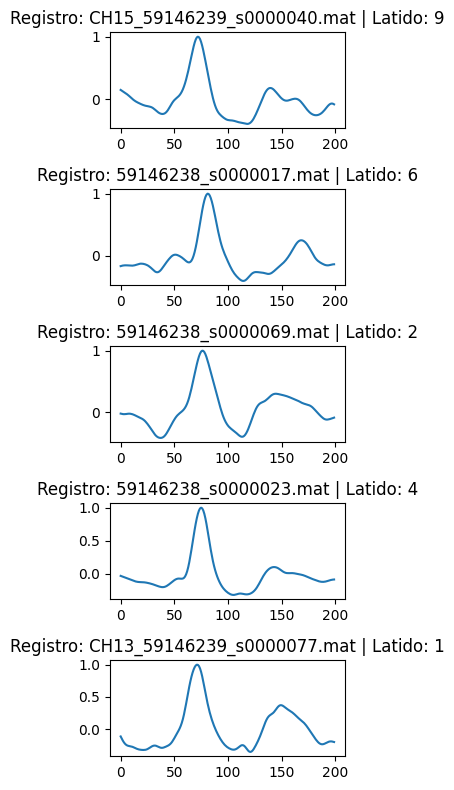

In [7]:
# ============================
# --- FILTRADO DE SEÑALES ---
# ============================

FS = 198.46762  # Frecuencia de muestreo fija

def butter_bandpass_filter(data, lowcut=0.5, highcut=20, fs=FS, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

def filtrar_icg(icg_raw, fs=FS):
    icg_bandpassed = butter_bandpass_filter(icg_raw, 0.5, 20, fs)
    icg_filtered = savgol_filter(icg_bandpassed, window_length=25, polyorder=3)
    return icg_filtered

# ============================
# --- PROCESAMIENTO DE DATOS ---
# ============================

def leer_measures(filepath):
    if filepath.endswith('.mat'):
        data = sio.loadmat(filepath)
        return data['measure']
    return None

def procesar_archivo(filepath):
    try:
        measures = leer_measures(filepath)
        if measures is None:
            return []

        ecg = measures[0, 1]['data'][0, 0].squeeze()
        r_peaks = (measures[2, 1]['data'][0, 0].flatten() * FS).astype(int)

        # Derivar la impedancia para obtener ICG
        impedance_data = measures[1, 1]['data'][0, 0]
        #obtenemos icg como derivada de la impedancia
        icg_raw = np.gradient(impedance_data.flatten())
        icg_filtrada = filtrar_icg(icg_raw)

        segmentos = []
        for i, r in enumerate(r_peaks):
            if r - 50 >= 0 and r + 150 < len(icg_filtrada):
                segmento = icg_filtrada[r - 50: r + 150]
                # Normalizar en amplitud (estandarizar)
                max_amplitude = np.max(np.abs(segmento))
                if max_amplitude == 0:
                    max_amplitude = 1
                segment_norm = segmento / max_amplitude

                segmentos.append({
                    'registro': os.path.basename(filepath),
                    'latido': i,
                    'icg_segment': segment_norm
                })
        return segmentos

    except Exception as e:
        print(f"Error en archivo {filepath}: {e}")
        return []

# ============================
# --- LOOP Y EXPORTACIÓN ---
# ============================

drive.mount('/content/drive')

root_dir = '/content/drive/MyDrive/HeartCycle'
carpetas = ['59146237', '59146238', '59146239']
resultados = []

for carpeta in carpetas:
    folder_path = os.path.join(root_dir, carpeta)
    for archivo in tqdm(os.listdir(folder_path), desc=f"Procesando {carpeta}"):
        if archivo.endswith('.mat'):
            full_path = os.path.join(folder_path, archivo)
            resultados.extend(procesar_archivo(full_path))

# Crear DataFrame y guardar
df_segments = pd.DataFrame(resultados)
df_segments.to_csv('/content/icg_segmentos_filtrados.csv', index=False)
print(" Segmentos guardados en CSV.")

# ============================
# --- VISUALIZACIÓN ---
# ============================

# Visualiza 5 segmentos aleatorios
if not df_segments.empty:
    print("\n Graficando 5 segmentos ICG aleatorios...")
    muestras = df_segments.sample(n=5, random_state=42)

    plt.figure(figsize=(3, 8))
    for idx, row in enumerate(muestras.itertuples()):
        plt.subplot(5, 1, idx + 1)
        plt.plot(row.icg_segment)
        plt.title(f"Registro: {row.registro} | Latido: {row.latido}")
        plt.tight_layout()
    plt.show()


Next, we want to create a second dataset which, unlike the previous one, will include all subcomplexes except for subcomplex u. This is done so that, when performing clustering later, those u subcomplexes do not introduce noise, as they do not provide any useful information about the ICG. For this purpose a Random Forest Algorithm is applied.

In [8]:
"""
Versión mejorada que permite:
1. Ajustar fácilmente el **porcentaje de segmentos ‘U’** mediante un umbral de probabilidad (`PROB_THRESHOLD`).
2. Forzar una nueva ejecución eliminando cachés previos con `FORCE_RESET`.
3. Mostrar un resumen final del reparto V/U para que puedas iterar hasta aproximarte al 10 % de ‘U’.

Instrucciones rápidas
--------------------
* Si ya tienes **segment_labels.csv** y **rf_model.pkl**, el script sólo volverá a generar las predicciones.
* Cambia `PROB_THRESHOLD` (0–1).  Cuanto más alto, más exigente → más ‘U’.
* Pon `FORCE_RESET = True` si quieres ignorar/descartar los archivos guardados y empezar de cero.
"""


# ---------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------
RANDOM_STATE   = 42           # reproducibilidad total
PROB_THRESHOLD = 0.7         # ↑ → más segmentos etiquetados como ‘U’
FORCE_RESET    = False        # True para ignorar etiquetas/modelo previos

LABELS_FILE        = Path("segment_labels.csv")
MODEL_FILE         = Path("rf_model.pkl")
PREDICTED_FILE     = Path("icg_segments_with_predictions.csv")
VALID_SEGMENTS_PKL = Path("segments_valid.pkl")

np.random.seed(RANDOM_STATE)

# ---------------------------------------------------------------------
# Función de extracción de características
# ---------------------------------------------------------------------

def extract_features(segments):
    feats = []
    for seg in segments:
        seg = np.asarray(seg)
        feats.append([
            np.mean(seg),
            np.std(seg),
            np.max(seg),
            np.min(seg),
            skew(seg),
            kurtosis(seg),
        ])
    return np.asarray(feats)

# ---------------------------------------------------------------------
# 0) Cargar df_segments
# ---------------------------------------------------------------------
assert "df_segments" in globals(), (
    "Debes tener cargado un DataFrame llamado df_segments con la columna 'Segment'."
)

# ---------------------------------------------------------------------
# 1) ¿Eliminar archivos previos?
# ---------------------------------------------------------------------
if FORCE_RESET:
    for f in [LABELS_FILE, MODEL_FILE, PREDICTED_FILE, VALID_SEGMENTS_PKL]:
        if f.exists():
            f.unlink()
    print("🗑️  Archivos antiguos eliminados — se inicia desde cero.")

# ---------------------------------------------------------------------
# 2) Cargar o crear etiquetas + modelo
# ---------------------------------------------------------------------
if LABELS_FILE.exists() and MODEL_FILE.exists():
    print("🔁 Encontrados archivos previos. Cargando…")
    sampled_df = pd.read_csv(LABELS_FILE)
    with open(MODEL_FILE, "rb") as f:
        rf = pickle.load(f)
else:
    print("🆕 No existen etiquetas/modelo. Procediendo a etiquetar 100 segmentos…")
    NUM_SAMPLES = 100
    BATCH_SIZE  = 4
    sampled_df  = df_segments.sample(NUM_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
    labels = []

    for i in range(0, NUM_SAMPLES, BATCH_SIZE):
        batch = sampled_df.iloc[i:i+BATCH_SIZE]
        fig, axs = plt.subplots(1, len(batch), figsize=(16,4))
        if len(batch) == 1:
            axs = [axs]
        for ax, (_, row) in zip(axs, batch.iterrows()):
            ax.plot(row["icg_segment"], lw=1)
            ax.set_title(f"Idx {row.name}")
            ax.grid(True)
        plt.tight_layout(); plt.show()

        display(HTML(
            f"<b>Introduce {len(batch)} etiquetas (V válido / U inválido) separadas por espacio:</b>"
        ))
        #input("Pulsa Enter cuando estés lista para escribir las etiquetas…")
        while True:
            batch_labels = input("Etiquetas: ").upper().split()
            if len(batch_labels) == len(batch) and all(l in {"V","U"} for l in batch_labels):
                break
            print("❌ Revisa que has escrito la cantidad correcta y sólo V/U.")
        labels.extend(batch_labels)

    sampled_df["Label"] = labels
    sampled_df.to_csv(LABELS_FILE, index=False)
    files.download(LABELS_FILE)

    # Entrenamiento RF
    X = extract_features(sampled_df["icg_segment"])
    y = sampled_df["Label"].map({"V":1, "U":0}).to_numpy()
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced")
    rf.fit(X_tr, y_tr)
    print("\n📊 Evaluación en el 30 % de los etiquetados:")
    print(classification_report(y_te, rf.predict(X_te), target_names=["U","V"]))

    with open(MODEL_FILE, "wb") as f:
        pickle.dump(rf, f)
    files.download(MODEL_FILE)

# ---------------------------------------------------------------------
# 3) Aplicar modelo a todos los segmentos con umbral personalizado
# ---------------------------------------------------------------------
proba_all = rf.predict_proba(extract_features(df_segments["icg_segment"]))[:,1]  # prob de clase 'V'
df_segments["Predicted_Label"] = np.where(proba_all >= PROB_THRESHOLD, "V", "U")

# ---------------------------------------------------------------------
# 4) Guardar y descargar resultados
# ---------------------------------------------------------------------
df_segments.to_csv(PREDICTED_FILE, index=False)
files.download(PREDICTED_FILE)

valid_segments = df_segments[df_segments["Predicted_Label"] == "V"].copy()
valid_segments.to_pickle(VALID_SEGMENTS_PKL)
files.download(VALID_SEGMENTS_PKL)

# ---------------------------------------------------------------------
# 5) Resumen rápido
# ---------------------------------------------------------------------
num_total = len(df_segments)
num_u     = (df_segments["Predicted_Label"] == "U").sum()
print(f"\n🔎 Resumen => Total beats: {num_total:,}  |  ‘U’: {num_u}  ({num_u / num_total:.2%})  |  ‘V’: {num_total - num_u}")


🔁 Encontrados archivos previos. Cargando…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🔎 Resumen => Total beats: 1,657  |  ‘U’: 87  (5.25%)  |  ‘V’: 1570


U and V distribution

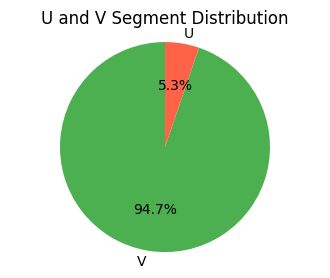

In [9]:
# Contar la cantidad de segmentos de tipo V y U
label_counts = df_segments['Predicted_Label'].value_counts()

# Graficar distribución de segmentos V y U
plt.figure(figsize=(4, 3))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF6347'])
plt.title("U and V Segment Distribution")
plt.axis('equal')  # Asegura que el gráfico sea un círculo
plt.show()


Here the code shows a plot of a random U segment that has been eliminated. As this DB has really low number of U segments, this code may show an error as there are not U segments to plot.

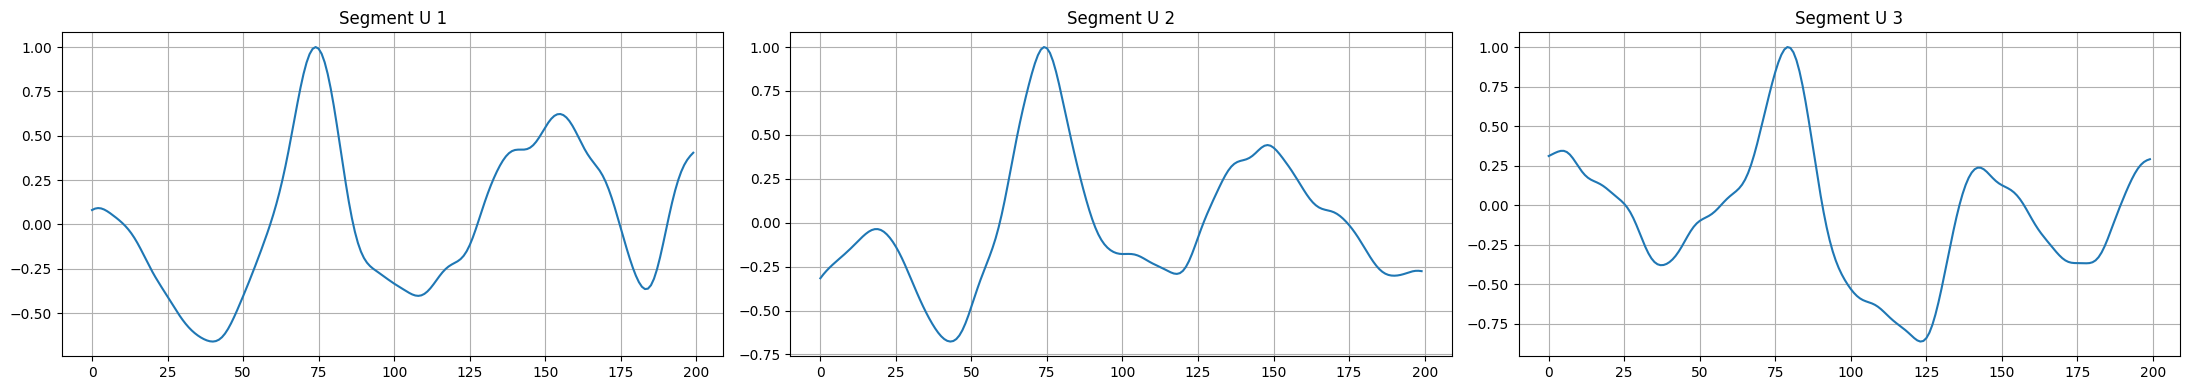

In [10]:
# Filtrar los segmentos clasificados como 'U'
u_segments = df_segments[df_segments['Predicted_Label'] == 'U']

# Seleccionar un número aleatorio de segmentos 'U' para visualizar
num_segments_to_show = 3
random_u_segments = u_segments.sample(n=num_segments_to_show)

# Graficar los segmentos 'U' seleccionados
plt.figure(figsize=(22, 4))

for i, (_, row) in enumerate(random_u_segments.iterrows()):
    plt.subplot(1, num_segments_to_show, i + 1)
    plt.plot(row['icg_segment'])
    plt.title(f"Segment U {i+1}")
    plt.grid(True)

plt.tight_layout()
plt.show()


###Delineation Algorithm for each characteristic Point:

####C point detection:

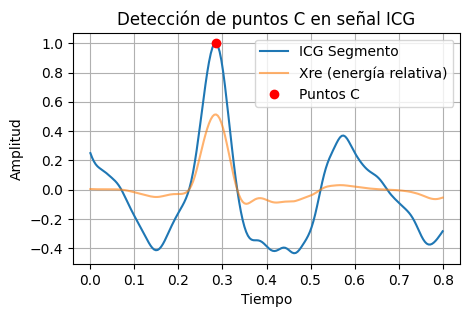

In [11]:
def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)

    for n in range(len(signal)):
        i1 = max(0, n - long_len // 2)
        i2 = min(len(signal), n + long_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)

        j1 = max(0, n - short_len // 2)
        j2 = min(len(signal), n + short_len // 2)
        short_energy = np.sum(signal[j1:j2] ** 2)

        if long_energy != 0:
            c = short_energy / long_energy
            Xre[n] = signal[n] * c
    return Xre

def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)

    # Thresholds
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 and sorted_peaks[-2] > np.mean(Xre) else sorted_peaks[-1]

    Thr_max = 0.2 * maxval
    Thr_min = 0.02 * maxval

    C_peaks = []
    active = False
    start_idx = 0

    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active = True
            start_idx = i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if len(C_peaks) == 0 or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    # Filtrar según intervalos C-C
    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            if len(prev_cc) == 5:
                avg_cc = np.mean(prev_cc)
                if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                    final_C_peaks.append(p)
            else:
                final_C_peaks.append(p)

    return np.array(final_C_peaks), Xre

#Cogemos un segmento de icg cuya etiqueta sea V
icg_segment = valid_segments['icg_segment'].iloc[1000]
fs=250
C_peaks, Xre = detect_C_peaks(icg_segment, fs)

#Definimos el tiempo para representar en función del tiempo en lugar de muestras
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Representación
plt.figure(figsize=(5, 3))
plt.plot(tiempo, icg_segment, label="ICG Segmento")
plt.plot(tiempo, Xre, label="Xre (energía relativa)", alpha=0.6)
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="Puntos C")
plt.legend()
plt.title("Detección de puntos C en señal ICG")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


####B point detection:

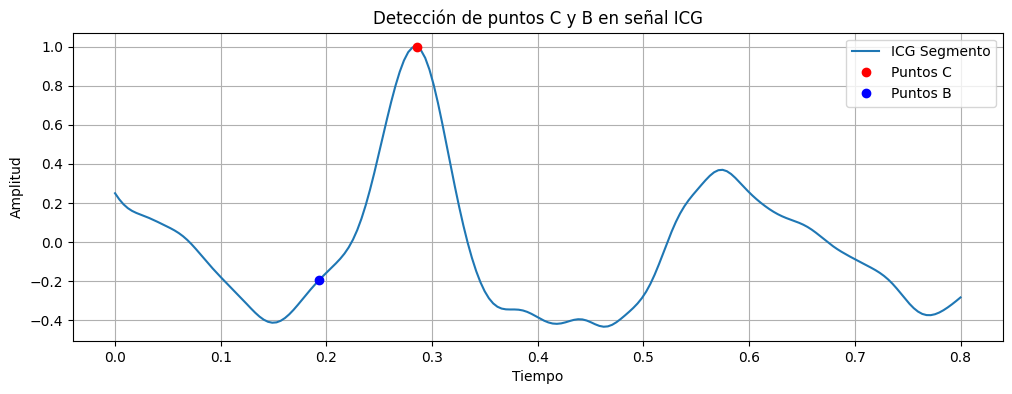

In [12]:
def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    # Paso 1: calcular límites de la ventana de búsqueda
    BlimL = max(0, int(Cpos - 0.09 * fs))  # 80 ms antes del C
    C_amp = icg_segment[Cpos]

    # Buscar BlimR: el índice más cercano a la izquierda donde la señal < Afrac * C_amp
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * C_amp:
            BlimR = i
            break
    else:
        BlimR = BlimL  # Si no se encuentra, que sea igual al límite inferior

    # Derivada primera (pendiente) de la señal
    slope = np.gradient(icg_segment)

    # Paso 2: búsqueda con Bslope1
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and (icg_segment[i] < icg_segment[i-1])) or abs(slope[i]) > Bslope1:
            return i

    # Paso 3: búsqueda con Bslope2
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i

    # Paso 4: si no se encuentra, retornar el mínimo de la ventana
    search_region = icg_segment[BlimL:BlimR+1]
    return BlimL + np.argmin(search_region)

B_points = []
for Cpos in C_peaks:
    B_idx = find_B_point(icg_segment, Cpos, fs)
    B_points.append(B_idx)

# Visualización
plt.figure(figsize=(12, 4))
plt.plot(tiempo, icg_segment, label="ICG Segmento")
plt.plot(tiempo[C_peaks], icg_segment[C_peaks], 'ro', label="Puntos C")
plt.plot(tiempo[B_points], icg_segment[B_points], 'bo', label="Puntos B")
plt.legend()
plt.title("Detección de puntos C y B en señal ICG")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


####X point detection:

<ipython-input-13-4cd84d6488c2>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-13-4cd84d6488c2>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


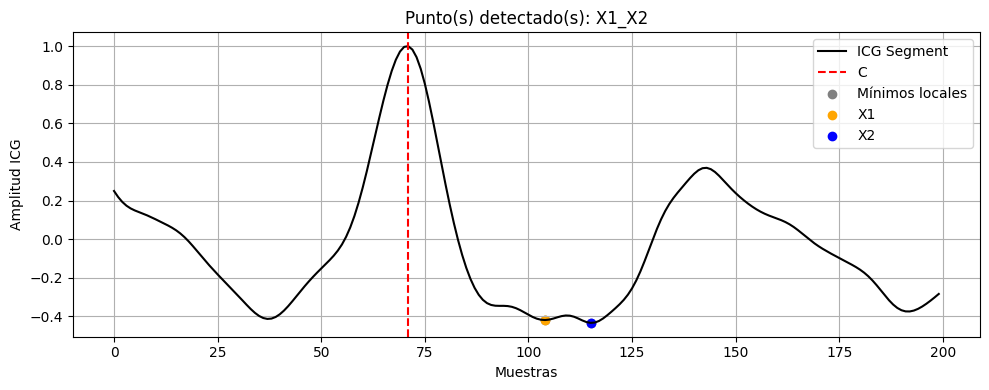

{'caso': 'X1_X2', 'X1': np.int64(104), 'X2': np.int64(115)}


In [13]:
def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):

    # 1. Definir ventana temporal (0.1s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        # Tomar los dos primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]

        # Comparar amplitudes
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) >= 3:
        # Tomar los tres primeros mínimos locales
        X1_idx = min_indices[0]
        X2_idx = min_indices[1]
        X3_idx = min_indices[2]

        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        amplitud_umbral = 0.05  # Puedes ajustar este valor según tu dataset
        idx = min_indices[0]

        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= amplitud_umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}

        elif idx == abs_min_idx and (C_index + 0.07 <= idx <= C_index + 0.22):
            resultado = {"caso": "X1", "X1": idx}

        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}

        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # 6. Graficar resultados
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(icg_segment, label='ICG Segment', color='black')
        plt.axvline(x=C_index, color='red', linestyle='--', label='C')

        # Ajustar índices locales a posición original
        min_plot_idx = min_indices + start
        plt.scatter(min_plot_idx, icg_segment[min_plot_idx], color='gray', label='Mínimos locales')

        if resultado["caso"] == "X":
            plt.scatter(resultado["X"] + start, icg_segment[resultado["X"] + start], color='blue', label='X')
        elif resultado["caso"] == "X1":
            plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start], color='orange', label='X1')
        elif resultado["caso"] == "X1_X2":
                plt.scatter(resultado["X1"] + start, icg_segment[resultado["X1"] + start],
                color='orange', label='X1')
                plt.scatter(resultado["X2"] + start, icg_segment[resultado["X2"] + start],
                color='blue', label='X2')
        plt.title(f"Punto(s) detectado(s): {resultado['caso']}")
        plt.xlabel("Muestras")
        plt.ylabel("Amplitud ICG")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


    # Ajustar índices al segmento original
    if resultado["caso"] == "X":
        resultado["X"] = resultado["X"] + start
    elif resultado["caso"] == "X1":
        resultado["X1"] = resultado["X1"] + start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] = resultado["X1"] + start
        resultado["X2"] = resultado["X2"] + start

    return resultado

segmento = valid_segments['icg_segment'].iloc[1000]
fs = 250
C_index, _ = detect_C_peaks(segmento, fs)

resultado = detectar_punto_X(segmento, C_index, fs, plot=True)
print(resultado)

####O point detection:

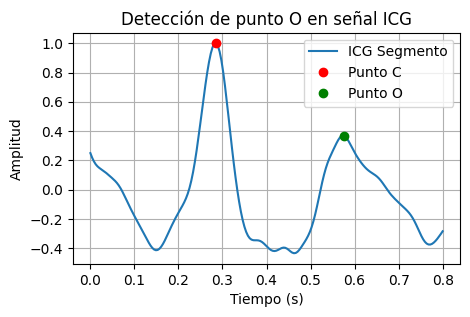

In [14]:
def detect_O_point(segment, C_index, fs):

    # Zona de búsqueda: 0.1s a 0.5s después del punto C
    start_search = C_index + int(0.2 * fs)  # 0.2 segundos después de C
    end_search = C_index + int(0.5 * fs)    # 0.5 segundos después de C

    # Asegurar que los índices no se salgan del rango
    end_search = min(end_search, len(segment))

    # Extraer la región de búsqueda
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None  # No hay espacio para buscar

    # Buscar máximos locales
    peaks, _ = signal.find_peaks(search_region)

    if len(peaks) == 0:
        return None  # No se encontró ningún máximo local

    # Elegir el pico de mayor amplitud (el más alto)
    peak_amplitudes = search_region[peaks]
    max_peak_idx = peaks[np.argmax(peak_amplitudes)]

    # Convertir índice relativo a índice absoluto en el segmento
    O_index = start_search + max_peak_idx
    return O_index

# Suponiendo que ya tienes detectados los puntos C en los segmentos
# Si se ha detectado al menos un punto C
if len(C_peaks) > 0:
    C_idx = C_peaks[0]  # Suponiendo un solo punto C por segmento
    O_idx = detect_O_point(icg_segment, C_idx, fs)

    # Representación
    tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(5, 3))
    plt.plot(tiempo, icg_segment, label="ICG Segmento")
    plt.plot(tiempo[C_idx], icg_segment[C_idx], 'ro', label="Punto C")
    if O_idx is not None:
        plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="Punto O")
    plt.legend()
    plt.title("Detección de punto O en señal ICG")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()


####Z point detection:

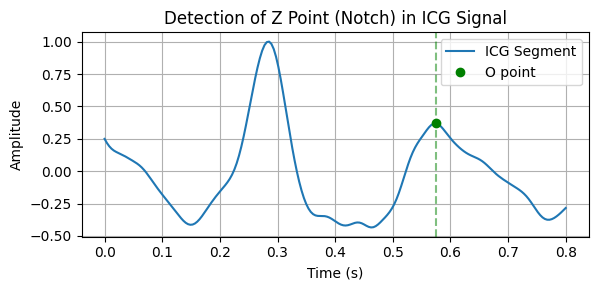

In [15]:
def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index

# Example of usage (assuming icg_segment, fs, and O_idx are defined)
Z_idx = detect_Z_point(icg_segment, O_idx, fs)

# Time vector for plotting
tiempo = np.linspace(0, len(icg_segment)/fs, len(icg_segment))

# Plotting the ICG signal with O and Z points
plt.figure(figsize=(6, 3))
plt.plot(tiempo, icg_segment, label="ICG Segment")
plt.plot(tiempo[O_idx], icg_segment[O_idx], 'go', label="O point")
if Z_idx is not None:
    plt.plot(tiempo[Z_idx], icg_segment[Z_idx], 'mo', label="Z point (notch)")
    plt.axvline(tiempo[Z_idx], color='m', linestyle='--', alpha=0.5)
plt.axvline(tiempo[O_idx], color='g', linestyle='--', alpha=0.5)
plt.title("Detection of Z Point (Notch) in ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


####Y point detection:

<ipython-input-13-4cd84d6488c2>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start = max(int(C_index + CXmin_samp), 0)
<ipython-input-13-4cd84d6488c2>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)


Usando X_idx en detectar_punto_Y: 115
No se detectaron mínimos locales entre X y O.


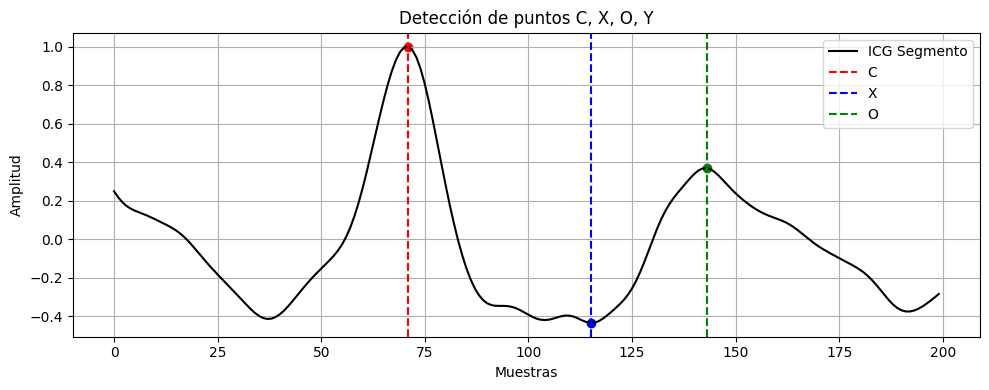

In [16]:
def detectar_punto_Y(icg_segment, resultado_X, O_index):
    # Determinar índice de inicio según el caso X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]  # usar X2 en este caso
    else:
        print("No se puede detectar Y: caso X no válido.")
        return None

    print("Usando X_idx en detectar_punto_Y:", X_idx)

    # Validar que X esté antes que O
    if X_idx >= O_index:
        print("No se puede detectar Y: X ocurre después de O.")
        return None

    # Extraer segmento entre X y O
    ventana_Y = icg_segment[X_idx:O_index + 1]

    # Buscar mínimos locales en esta ventana
    min_indices = argrelextrema(ventana_Y, np.less)[0]

    if len(min_indices) == 0:
        print("No se detectaron mínimos locales entre X y O.")
        return None

    # Tomar el mínimo local de menor amplitud
    Y_rel_idx = min_indices[np.argmin(ventana_Y[min_indices])]
    Y_abs_idx = X_idx + Y_rel_idx

    return Y_abs_idx


def plot_segmento_con_puntos(segmento, C_idx=None, X_idx=None, O_idx=None, Y_idx=None):
    plt.figure(figsize=(10, 4))
    plt.plot(segmento, label="ICG Segmento", color='black')

    if C_idx is not None:
        plt.axvline(x=C_idx, color='red', linestyle='--', label="C")
        plt.scatter([C_idx], [segmento[C_idx]], color='red')

    if X_idx is not None:
        plt.axvline(x=X_idx, color='blue', linestyle='--', label="X")
        plt.scatter([X_idx], [segmento[X_idx]], color='blue')

    if O_idx is not None:
        plt.axvline(x=O_idx, color='green', linestyle='--', label="O")
        plt.scatter([O_idx], [segmento[O_idx]], color='green')

    if Y_idx is not None:
        plt.axvline(x=Y_idx, color='magenta', linestyle='--', label="Y")
        plt.scatter([Y_idx], [segmento[Y_idx]], color='magenta')

    plt.legend()
    plt.title("Detección de puntos C, X, O, Y")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


segmento = valid_segments['icg_segment'].iloc[1000]
fs = 250
C_index, _ = detect_C_peaks(segmento, fs)
resultado = detectar_punto_X(segmento, C_index, fs, plot=False)
C_idx = C_index[0]
O_idx = detect_O_point(segmento, C_idx, fs)
Y_idx = detectar_punto_Y(segmento, resultado, O_idx)

# Aquí usas la función externa para plotear todos los puntos
if resultado["caso"] == "X":
    X_idx = resultado["X"]
elif resultado["caso"] == "X1":
    X_idx = resultado["X1"]
elif resultado["caso"] == "X1_X2":
    X_idx = resultado["X2"]
else:
    X_idx = None

plot_segmento_con_puntos(segmento, C_idx=C_index[0], X_idx=X_idx, O_idx=O_idx, Y_idx=Y_idx)

###Delineation Algorithm for all characteristic Points:

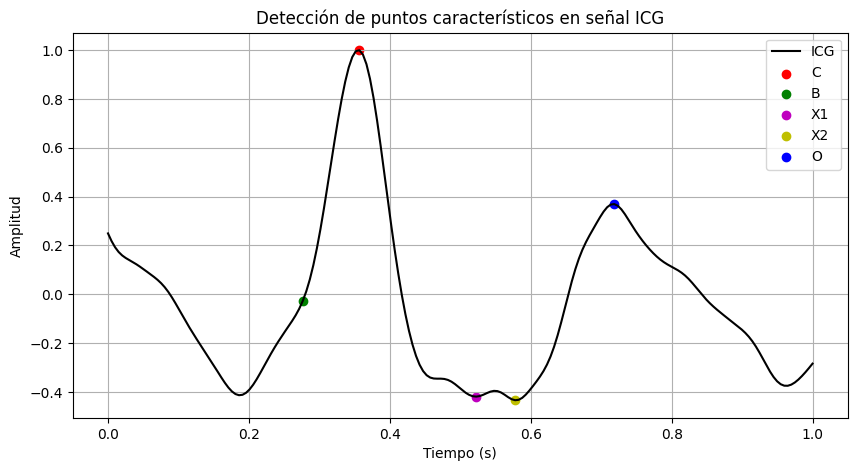

In [17]:
# ===================== #
#    1. FUNCIONES       #
# ===================== #

def relative_energy(signal, fs, long_win=0.95, short_win=0.14):
    long_len = int(long_win * fs)
    short_len = int(short_win * fs)
    Xre = np.zeros_like(signal)
    for n in range(len(signal)):
        i1, i2 = max(0, n - long_len // 2), min(len(signal), n + long_len // 2)
        j1, j2 = max(0, n - short_len // 2), min(len(signal), n + short_len // 2)
        long_energy = np.sum(signal[i1:i2] ** 2)
        short_energy = np.sum(signal[j1:j2] ** 2)
        if long_energy != 0:
            Xre[n] = signal[n] * (short_energy / long_energy)
    return Xre


def detect_C_peaks(icg_filtered, fs):
    Xre = relative_energy(icg_filtered, fs)
    sorted_peaks = np.sort(Xre[Xre > np.mean(Xre)])
    maxval = sorted_peaks[-2] if len(sorted_peaks) > 1 else sorted_peaks[-1]
    Thr_max, Thr_min = 0.2 * maxval, 0.02 * maxval

    C_peaks, active = [], False
    for i in range(1, len(Xre)):
        if not active and Xre[i] > Thr_max:
            active, start_idx = True, i
        elif active and Xre[i] < Thr_min:
            end_idx = i
            peak_idx = start_idx + np.argmax(Xre[start_idx:end_idx])
            if not C_peaks or (peak_idx - C_peaks[-1]) > int(0.25 * fs):
                C_peaks.append(peak_idx)
            active = False

    final_C_peaks = []
    for i, p in enumerate(C_peaks):
        if i < 5:
            final_C_peaks.append(p)
        else:
            prev_cc = np.diff(final_C_peaks[-5:])
            avg_cc = np.mean(prev_cc)
            if (p - final_C_peaks[-1]) > 1.7 * avg_cc:
                final_C_peaks.append(p)
    return np.array(final_C_peaks), Xre


def find_B_point(icg_segment, Cpos, fs, Afrac=0.2, Bslope1=0.11, Bslope2=0.08):
    BlimL = max(0, int(Cpos - 0.08 * fs))
    for i in range(Cpos - 1, BlimL, -1):
        if icg_segment[i] <= Afrac * icg_segment[Cpos]:
            BlimR = i
            break
    else:
        BlimR = BlimL
    slope = np.gradient(icg_segment)
    for i in range(BlimR, BlimL, -1):
        if (i > 0 and icg_segment[i] < icg_segment[i-1]) or abs(slope[i]) > Bslope1:
            return i
    for i in range(BlimR, BlimL, -1):
        if abs(slope[i]) > Bslope2:
            return i
    return BlimL + np.argmin(icg_segment[BlimL:BlimR+1])


def detectar_punto_X(icg_segment, C_index, fs, plot=False, suavizar=True):
    # 1. Definir ventana temporal (0.05s a 0.4s después de C)
    CXmin_s, CXmax_s = 0.05, 0.4
    CXmin_samp, CXmax_samp = int(fs * CXmin_s), int(fs * CXmax_s)
    start = max(int(C_index + CXmin_samp), 0)
    end = min(int(C_index + CXmax_samp), len(icg_segment) - 1)
    ventana = icg_segment[start:end]

    if len(ventana) < 3:
        return {"caso": "ninguno", "mensaje": "Ventana demasiado corta"}

    # 2. Suavizar señal si está activado
    if suavizar:
        ventana = gaussian_filter1d(ventana, sigma=1)

    # 3. Detectar mínimos locales
    min_indices = argrelextrema(ventana, np.less)[0]
    if len(min_indices) == 0:
        return {"caso": "ninguno", "mensaje": "No se detectaron mínimos locales"}

    # 4. Detectar mínimo global
    abs_min_idx = np.argmin(ventana)

    # 5. Clasificación según mínimos detectados
    if len(min_indices) == 1:
        idx = min_indices[0]
        if idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    elif len(min_indices) == 2:
        X1_idx, X2_idx = min_indices[0], min_indices[1]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X1_idx] > ventana[X2_idx]:
            resultado = {"caso": "X", "X": X2_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    else:
        X1_idx, X2_idx, X3_idx = min_indices[:3]
        amp_diff = abs(ventana[X1_idx] - ventana[X2_idx])
        umbral = 0.05
        idx = min_indices[0]
        if ventana[X1_idx] < ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif ventana[X1_idx] > ventana[X2_idx] and amp_diff <= umbral:
            resultado = {"caso": "X1_X2", "X1": X1_idx, "X2": X2_idx}
        elif idx == abs_min_idx and (0.07*fs <= idx <= 0.22*fs):
            resultado = {"caso": "X1", "X1": idx}
        elif ventana[X3_idx] < ventana[X2_idx]:
            resultado = {"caso": "X", "X": X3_idx}
        else:
            resultado = {"caso": "X", "X": abs_min_idx}

    # Ajuste de índices absolutos
    if resultado["caso"] == "X":
        resultado["X"] += start
    elif resultado["caso"] == "X1":
        resultado["X1"] += start
    elif resultado["caso"] == "X1_X2":
        resultado["X1"] += start
        resultado["X2"] += start

    return resultado


def detect_O_point(segment, C_index, fs):
    start_search = C_index + int(0.2 * fs)
    end_search = min(C_index + int(0.5 * fs), len(segment))
    search_region = segment[start_search:end_search]
    if len(search_region) == 0:
        return None
    peaks, _ = signal.find_peaks(search_region)
    if len(peaks) == 0:
        return None
    max_peak_idx = peaks[np.argmax(search_region[peaks])]
    return start_search + max_peak_idx


def detect_Z_point(segment, O_index, fs):
    # Define search window (start just after O, up to 0.1s after)
    start_search = O_index + int(0.005 * fs)
    end_search = O_index + int(0.15 * fs)
    end_search = min(end_search, len(segment))

    # Extract search region
    search_region = segment[start_search:end_search]

    if len(search_region) == 0:
        return None

    # Invert the signal to find local minima as peaks
    inverted_region = -search_region
    peaks, _ = signal.find_peaks(inverted_region)

    if len(peaks) == 0:
        return None  # No local minima found

    # Choose the first local minimum
    Z_index = start_search + peaks[0]
    return Z_index


def detectar_punto_Y(icg_segment, resultado_X, O_index, fs):
    # Selección del índice de X
    if resultado_X["caso"] == "X":
        X_idx = resultado_X["X"]
    elif resultado_X["caso"] == "X1":
        X_idx = resultado_X["X1"]
    elif resultado_X["caso"] == "X1_X2":
        X_idx = resultado_X["X2"]
    else:
        return None

    if X_idx >= O_index:
        return None

    # Definir ventana temporal tras X
    min_offset = int(0.06 * fs)  # 60 ms
    max_offset = O_index
    inicio = X_idx + min_offset
    fin = min(X_idx + max_offset, O_index + 1)

    if fin <= inicio or fin > len(icg_segment):
        return None

    ventana_Y = icg_segment[inicio:fin]

    # Detectar mínimos locales
    min_idx = argrelextrema(ventana_Y, np.less)[0]

    for idx in min_idx:
        # Verificar que la curva baja antes y sube después (mínimo local "válido")
        if 1 <= idx < len(ventana_Y) - 1:
            if ventana_Y[idx - 1] > ventana_Y[idx] < ventana_Y[idx + 1]:
                return inicio + idx

    # Si no hay mínimos válidos con esa forma
    return None
# ===================== #
#     2. CARGA & PLOT   #
# ===================== #

fs = 200
segmento_idx = 1000
segmento = valid_segments['icg_segment'].iloc[segmento_idx]

# Detectar todos los puntos
C_peaks, _ = detect_C_peaks(segmento, fs)
B_points = find_B_point(segmento, C_peaks[0], fs)
X_result = detectar_punto_X(segmento, C_peaks[0], fs)
O_point = detect_O_point(segmento, C_peaks[0], fs)
Z_point = detect_Z_point(segmento, O_point, fs)
Y_point = detectar_punto_Y(segmento, X_result, O_point, fs)

def plot_icg_with_points(icg_segment, fs,
                         C_idx, B_idxs, X_res, O_idx, Z_idx, Y_idx):
    time = np.linspace(0, len(icg_segment)/fs, len(icg_segment))
    plt.figure(figsize=(10,5))
    plt.plot(time, icg_segment, color='k', label='ICG')

    plt.scatter(time[C_idx], icg_segment[C_idx], color='r', label='C')
    plt.scatter(time[B_idxs], icg_segment[B_idxs], color='g', label='B')


    if X_res['caso']=='X':
        plt.scatter(time[X_res['X']], icg_segment[X_res['X']], color='m', label='X')
    elif X_res['caso']=='X1':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1')
    elif X_res['caso']=='X1_X2':
        plt.scatter(time[X_res['X1']], icg_segment[X_res['X1']], color='m', label='X1')
        plt.scatter(time[X_res['X2']], icg_segment[X_res['X2']], color='y', label='X2')

    if O_idx is not None:
        plt.scatter(time[O_idx], icg_segment[O_idx], color='b', label='O')

    if Z_idx is not None:
        plt.scatter(time[Z_idx], icg_segment[Z_idx], color='c', label='Z')

    if Y_idx is not None:
        plt.scatter(time[Y_idx], icg_segment[Y_idx], color='orange', label='Y')

    plt.legend()
    plt.title('Detección de puntos característicos en señal ICG')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()

# Llamada al plot
plot_icg_with_points(segmento, fs, C_peaks[0], B_points, X_result, O_point, Z_point, Y_point)


###K-MEDOIDS + DTW (Clustering Algorithm)

First, we compute the DTW matrix

In [18]:
# dtw_matrix_compute.py
"""
Cálculo **único** de la matriz de distancias DTW (con ventana Sakoe‑Chiba) para
los segmentos válidos recortados.

* Espera que exista un `DataFrame` llamado **`df_valid_segments`** en memoria
  con la columna **`Segment`**.
* Recorta cada segmento desde el 42 % y crea `Segment_partial`.
* Calcula la matriz DTW por bloques para no desbordar RAM.
* Guarda:
  - `dtw_matrix.npy` — matriz completa (n×n)
  - `dtw_order_indices.npy` — orden de los índices del DataFrame usado
* Descarga ambos archivos para que puedas subirlos en futuras sesiones.

Ejecuta este script **una sola vez** o cuando quieras recalcular; después usa
`kmedoids_runs.py` para el clustering repetido.
"""

# --------------------- Configuración -------------------- #
RANDOM_STATE       = 12345
BLOCK_SIZE         = 200      # filas por bloque
DTW_RADIUS_RATIO   = 0.10     # ventana Sakoe = 10 % de la longitud
DTW_FILE           = Path("dtw_matrix.npy")
IDX_FILE           = Path("dtw_order_indices.npy")

# -------------------- Validaciones ---------------------- #
assert "valid_segments" in globals(), (
    "Debes cargar primero valid_segments (cargar ('segments_valid.pkl'))"
)

# -------------------- Recorte --------------------------- #

def crop_segments(df, col="icg_segment", start_ratio=0.42):
    df = df.copy()
    df["segment_partial"] = df[col].apply(lambda x: x[int(start_ratio * len(x)):])
    return df

print("✂️ Recortando segmentos al 42 %…")
df = crop_segments(valid_segments)
X = np.stack(df["segment_partial"].values)
(n_segments, seg_len) = X.shape
sakoe_radius = int(DTW_RADIUS_RATIO * seg_len)

# ------------------ Cargar o calcular ------------------- #
if DTW_FILE.exists() and IDX_FILE.exists():
    print("✅ Matriz DTW ya existe. Si quieres recalcular, borra los archivos y vuelve a ejecutar.")
else:
    print("🆕 Calculando matriz DTW (puede tardar)…")
    n_blocks = math.ceil(n_segments / BLOCK_SIZE)
    rows_accum = []
    for blk in range(n_blocks):
        start = blk * BLOCK_SIZE
        end   = min((blk + 1) * BLOCK_SIZE, n_segments)
        print(f"   · Bloque {blk + 1}/{n_blocks} — filas {start}:{end}")
        block = cdist_dtw(
            X[start:end], X,
            global_constraint="sakoe_chiba",
            sakoe_chiba_radius=sakoe_radius,
        )
        rows_accum.append(block)

    dtw_matrix = np.vstack(rows_accum)
    np.save(DTW_FILE, dtw_matrix)
    np.save(IDX_FILE, df.index.to_numpy())
    print(f"💾 Guardados {DTW_FILE} y {IDX_FILE}.")

    # Descarga inmediata para preservar en Drive / local
    files.download(DTW_FILE)
    files.download(IDX_FILE)

print("🎉 Proceso terminado. Ahora lanza kmedoids_runs.py para el clustering múltiple.")


✂️ Recortando segmentos al 42 %…
✅ Matriz DTW ya existe. Si quieres recalcular, borra los archivos y vuelve a ejecutar.
🎉 Proceso terminado. Ahora lanza kmedoids_runs.py para el clustering múltiple.


Obtain segments full length for the plots (they were cropped for a more accurate clustering)

In [19]:
# Extraer los segmentos completos
full_segments_array = np.stack(valid_segments['icg_segment'].values)

# Guardar el array como .npy para futuras cargas
np.save("full_segments.npy", full_segments_array)
print("✅ Archivo full_segments.npy guardado correctamente.")


✅ Archivo full_segments.npy guardado correctamente.


We apply KMedoids 5 times with k=5, and obtain for each iteration to which cluster a segment belongs. As a result, we obtain 25 plots, one per cluster (there are 5 clusters in each iteration and a total of 5 iterations). Each plot contains: in grey all segments that belong to that cluster and in black the representative segment based on the medoids. Then, the delineation algorithm is applied to the representative segment and therefore, the characteristic points distribution is displayed.

In [24]:
# kmedoids_runs_delineados.py
"""
Aplica K-Medoids 5 veces (K=5) sobre la matriz DTW y genera:
▪ CSV de asignaciones por ejecución
▪ CSV de distribuciones de cluster
▪ 25 figuras: todos los segmentos en gris, medoide en negro,
  y puntos B,C,X,O,Y,Z sobre el medoide con eje tiempo (s)
"""


# ============ PARÁMETROS GENERALES =============
K = 5                       # nº de clusters
SEEDS = [0, 1, 2, 3, 4]     # cinco ejecuciones
FS = 250             # Hz  ← para pasar de muestras a segundos

DTW_MATRIX_FILE  = "dtw_matrix.npy"
ORDER_IDX_FILE   = "dtw_order_indices.npy"
FULL_SEGMENTS_FILE = "full_segments.npy"

# ============ CARGA DE ARCHIVOS =============
print("📂 Cargando archivos…")
dtw_matrix   = np.load(DTW_MATRIX_FILE)
order_indices = np.load(ORDER_IDX_FILE)
full_segments = np.load(FULL_SEGMENTS_FILE, allow_pickle=True)

segment_ids = np.arange(len(dtw_matrix))
df_valid = pd.DataFrame({"Segment_ID": segment_ids})

# ============ FUNCIONES DE DELINEACIÓN ============
#  (Pega aquí todas tus funciones: relative_energy, detect_C_peaks,
#   find_B_point, detectar_punto_X, detect_O_point,
#   detect_Z_point, detectar_punto_Y)
# --------------------------------------------------

# ============ K-MEDOIDS 5 EJECUCIONES =============
for run_idx, seed in enumerate(SEEDS, start=1):
    print(f"⏳ Ejecutando K-Medoids run {run_idx} (seed={seed})…")
    np.random.seed(seed)
    init_medoids = np.random.choice(len(dtw_matrix), K, replace=False).tolist()
    kmed = kmedoids(dtw_matrix, init_medoids, data_type="distance_matrix")
    kmed.process()

    clusters = kmed.get_clusters()
    medoids  = kmed.get_medoids()

    # Etiquetas por segmento
    labels = np.empty(len(dtw_matrix), dtype=int)
    for cid, idxs in enumerate(clusters):
        labels[idxs] = cid
    df_valid[f"cluster_run{run_idx}"] = labels

    # NUEVO ───────── marcar los medoides ─────────
    col_med = f"medoid_run{run_idx}"
    df_valid[col_med] = 0            # 0 = no-medoide
    df_valid.loc[medoids, col_med] = 1

    # Carpeta de salida
    out_dir = f"plots_run{run_idx}"
    os.makedirs(out_dir, exist_ok=True)

    # -------- FIGURAS POR CLUSTER --------
    for cid, idxs in enumerate(clusters):
        plt.figure(figsize=(10, 4))

        # Todos los segmentos en gris (eje tiempo)
        for idx in idxs:
            seg = full_segments[idx]
            t   = np.arange(len(seg)) / FS
            plt.plot(t, seg, color="lightgray", linewidth=0.7)

        # Medoide en negro
        med_idx  = medoids[cid]
        med_seg  = full_segments[med_idx]
        t_med    = np.arange(len(med_seg)) / FS
        plt.plot(t_med, med_seg, color="black", linewidth=2, label="Medoid")

        # ---------- Delineación sobre el medoide ----------
        try:
            C_peaks, _ = detect_C_peaks(med_seg, FS)
            if len(C_peaks):
                C_idx = C_peaks[0]
                B_idx = find_B_point(med_seg, C_idx, FS)
                X_res = detectar_punto_X(med_seg, C_idx, FS)
                O_idx = detect_O_point(med_seg, C_idx, FS)
                Z_idx = detect_Z_point(med_seg, O_idx, FS)
                Y_idx = detectar_punto_Y(med_seg, X_res, O_idx, FS)

                # Límites de amplitud
                y_min, y_max = plt.ylim()

                # Función auxiliar para dibujar líneas verticales
                def draw_line(t_idx, color, label=None):
                    if t_idx is not None:
                        t_val = t_med[t_idx]
                        plt.vlines(t_val, y_min, y_max, colors=color,
                                  linestyles="dashed", label=label)

                # Líneas verticales para cada punto
                draw_line(C_idx, "red",    "C")
                draw_line(B_idx, "green",  "B")

                if X_res["caso"] == "X":
                    draw_line(X_res["X"], "magenta", "X")
                elif X_res["caso"] == "X1":
                    draw_line(X_res["X1"], "magenta", "X1")
                elif X_res["caso"] == "X1_X2":
                    draw_line(X_res["X1"], "magenta", "X1")
                    draw_line(X_res["X2"], "yellow",  "X2")

                draw_line(O_idx, "blue",     "O")
                draw_line(Z_idx, "cyan",     "Z")
                draw_line(Y_idx, "orange",   "Y")

        except Exception as e:
            print(f"⚠️  Run {run_idx} – Cluster {cid}: error en delineación → {e}")

        # ---------- Etiquetas y guardado ----------
        plt.title(f"Run {run_idx} – Cluster {cid+1}  ({len(idxs)} segmentos)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"cluster_{cid}.png"))
        plt.close()


# ============ CSV DE RESULTADOS =============
clusters_csv = "kmedoids_clusters_runs.csv"
df_valid.to_csv(clusters_csv, index=False)
files.download(clusters_csv)
print(f"📁 Guardado: {clusters_csv}")

# ============ DISTRIBUCIÓN POR RUN ==========
dist = {}
for i in range(1, 6):
    col = f"cluster_run{i}"
    dist[f"run{i}"] = df_valid[col].value_counts(normalize=True).sort_index().round(3)*100
df_dist = pd.DataFrame(dist).fillna(0)
dist_csv = "kmedoids_cluster_distribution.csv"
df_dist.to_csv(dist_csv)
files.download(dist_csv)
print(f"📊 Guardado: {dist_csv}")


📂 Cargando archivos…
⏳ Ejecutando K-Medoids run 1 (seed=0)…
⏳ Ejecutando K-Medoids run 2 (seed=1)…
⏳ Ejecutando K-Medoids run 3 (seed=2)…
⏳ Ejecutando K-Medoids run 4 (seed=3)…
⏳ Ejecutando K-Medoids run 5 (seed=4)…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📁 Guardado: kmedoids_clusters_runs.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📊 Guardado: kmedoids_cluster_distribution.csv


Once the clustering has been done, we do a mapping between the representative clusters obtained in the 5 iterations regarding if they have the same or really similar point distribution. This mapping is done based on definitions of "icg types" as explained in the paper of Benouar. As a result, we obtain a table where each representative icg segment is classified to a type. Moreover, plots are obtained showing all icg representative segments belonging to the same type so we can verify that all segments have the same or similar point distribution as described by hte types definition.

In [28]:
# Tu número de clusters y seeds
K = 5
SEEDS = [0, 1, 2, 3, 4]
FS = 250

# Cargar archivos
dtw_matrix = np.load("dtw_matrix.npy")
full_segments = np.load("full_segments.npy", allow_pickle=True)
df_valid = pd.read_csv("kmedoids_clusters_runs.csv")

# Definiciones de tipos de cluster
TIPO_DEFINICIONES = {
    0: [{"X", "O", "Z", "Y"}, {"X1", "Y", "O", "Z"}],
    1: [{"X", "O"}, {"X", "O", "Z"}],
    2: [{"X1", "X2", "Y", "O", "Z"}, {"X1", "X2", "Y", "O"}],
    3: [{"X1", "X2", "O", "Z"}, {"X1", "X2", "O"}],
    4: [{"X1", "O", "Z"}, {"X1", "O"}],
}

# ================== FUNCIONES DE DETECCIÓN DE PUNTOS ==================
# Asegúrate de pegar aquí tus funciones:
# detect_C_peaks, find_B_point, detectar_punto_X, detect_O_point, detect_Z_point, detectar_punto_Y
# =====================================================================

# Función para determinar qué puntos están presentes
def detectar_firma_puntos(segmento):
    try:
        puntos = set()
        C_peaks, _ = detect_C_peaks(segmento, FS)
        if len(C_peaks) == 0:
            return puntos
        C_idx = C_peaks[0]
        X_res = detectar_punto_X(segmento, C_idx, FS)
        O_idx = detect_O_point(segmento, C_idx, FS)
        Z_idx = detect_Z_point(segmento, O_idx, FS)
        Y_idx = detectar_punto_Y(segmento, X_res, O_idx, FS)

        if X_res["caso"] == "X":
            puntos.add("X")
        elif X_res["caso"] == "X1":
            puntos.add("X1")
        elif X_res["caso"] == "X1_X2":
            puntos.add("X1")
            puntos.add("X2")

        if O_idx is not None:
            puntos.add("O")
        if Z_idx is not None:
            puntos.add("Z")
        if Y_idx is not None:
            puntos.add("Y")

        return puntos
    except:
        return set()

# Función para mapear una firma a un tipo
def asignar_tipo(puntos_detectados):
    for tipo, definiciones in TIPO_DEFINICIONES.items():
        for definicion in definiciones:
            if puntos_detectados == definicion:
                return tipo
    return -1  # Tipo no reconocido

# ==================== PROCESO DE MAPEADO ====================
# Asignar tipo a cada cluster según puntos del medoide
tipo_cluster = {}  # (run_idx, cluster_id) -> tipo
for run_idx, seed in enumerate(SEEDS, start=1):
    for cid in range(K):
        medoid_idx = df_valid.index[
            (df_valid[f"cluster_run{run_idx}"] == cid) &
            (df_valid[f"medoid_run{run_idx}"] == 1)
        ][0]
        sig = full_segments[medoid_idx]
        puntos_detectados = detectar_firma_puntos(sig)

        asignado = False
        for tipo, combinaciones in TIPO_DEFINICIONES.items():
            for combo in combinaciones:
                if set(puntos_detectados) == combo:
                    tipo_cluster[(run_idx, cid)] = tipo
                    asignado = True
                    break
            if asignado:
                break
        if not asignado:
            tipo_cluster[(run_idx, cid)] = -1  # no encaja en ningún tipo

# Crear nueva tabla con los tipos asignados
df_mapeado = df_valid.copy()

for run_idx in range(1, 6):
    col = f"cluster_run{run_idx}"
    new_col = f"tipo_run{run_idx}"
    df_mapeado[new_col] = df_mapeado[col].apply(lambda cid: tipo_cluster.get((run_idx, cid), -1))

# Guardar
df_mapeado.to_csv("kmedoids_clusters_mapeados.csv", index=False)
print("✅ Archivo guardado: kmedoids_clusters_mapeados.csv")
from google.colab import files
files.download("kmedoids_clusters_mapeados.csv")

# ============================================================
#  VISUALIZAR LOS MEDOIDES AGRUPADOS POR TIPO MORFOLÓGICO
# ============================================================

# Recopilamos la información ya calculada --------------------
medoid_info = []   # (tipo, run_idx, cluster_id, medoid_idx, puntos_detectados)

for (run_idx, cid), tipo in tipo_cluster.items():
    if tipo == -1:
        continue                        # clusters no clasificados
    medoid_idx = df_valid.index[
        (df_valid[f"cluster_run{run_idx}"] == cid) &
        (df_valid[f"medoid_run{run_idx}"] == 1)
    ][0]
    sig        = full_segments[medoid_idx]
    puntos     = detectar_firma_puntos(sig)
    medoid_info.append((tipo, run_idx, cid, medoid_idx, puntos))

# --------------  FIGURAS POR TIPO (0-4)  --------------------
os.makedirs("tipo_plots", exist_ok=True)
for tipo in sorted(TIPO_DEFINICIONES.keys()):
    # todos los medoides de este tipo
    medos = [m for m in medoid_info if m[0] == tipo]
    if not medos:
        continue

    n = len(medos)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
    if n == 1:          # cuando solo hay un medoide, axes no es lista
        axes = [axes]

    for ax, (t, run_idx, cid, med_idx, puntos) in zip(axes, medos):
        seg = full_segments[med_idx]
        t_sig = np.arange(len(seg)) / FS
        ax.plot(t_sig, seg, color="black", lw=1)

        # volvemos a marcar los puntos como líneas verticales
        C_peaks, _ = detect_C_peaks(seg, FS)
        if C_peaks:
            C_idx = C_peaks[0]
            X_res = detectar_punto_X(seg, C_idx, FS)
            O_idx = detect_O_point(seg, C_idx, FS)
            if O_idx is not None:
                Z_idx = detect_Z_point(seg, O_idx, FS)
            else:
                Z_idx = None
            O_idx = detect_O_point(seg, C_idx, FS)
            if O_idx is not None:
                Y_idx = detectar_punto_Y(seg, X_res, O_idx, FS)
            else:
                Y_idx = None

            y_min, y_max = ax.get_ylim()
            def vline(idx, color, lab):
                ax.vlines(idx/FS, y_min, y_max,
                          colors=color, linestyles="dashed", label=lab)

            vline(C_idx, "red", "C")

            if X_res["caso"] == "X":
                vline(X_res["X"], "magenta", "X")
            elif X_res["caso"] == "X1":
                vline(X_res["X1"], "magenta", "X1")
            elif X_res["caso"] == "X1_X2":
                vline(X_res["X1"], "magenta", "X1")
                vline(X_res["X2"], "yellow",  "X2")

            if "O" in puntos: vline(O_idx, "blue",  "O")
            if "Z" in puntos: vline(Z_idx, "cyan",  "Z")
            if "Y" in puntos: vline(Y_idx, "orange","Y")

        ax.set_title(f"Tipo {tipo}  |  Run {run_idx}  Cluster {cid}")
        ax.set_ylabel("Amp.")
        ax.legend(loc="upper right", fontsize="small")

    axes[-1].set_xlabel("Tiempo (s)")
    fig.tight_layout()
    fig.savefig(f"tipo_plots/tipo_{tipo}.png")
    plt.close(fig)

print("✅ Se han guardado las figuras por tipo en la carpeta 'tipo_plots/'")

# --- GUARDAR EL MAPEADO (run,cluster) → tipo ---
pd.DataFrame([
    {"run": run, "cluster": cid, "tipo": t}
    for (run, cid), t in tipo_cluster.items()
]).to_csv("cluster_tipo_mapping.csv", index=False)
print("📁 Guardado: cluster_tipo_mapping.csv")

# ------------------------------------------------------------------
# TABLA “(run,cluster) → tipo”  Y VISTA RÁPIDA
# ------------------------------------------------------------------
import pandas as pd
from tabulate import tabulate   # opcional, solo para imprimir bonito

map_df = pd.read_csv("cluster_tipo_mapping.csv")          # ya lo guardaste antes
map_df = map_df.sort_values(["run", "cluster"]).reset_index(drop=True)

# 1.a) Guardar como Excel/CSV (si quieres abrirlo fuera de Colab)
map_df.to_excel("tabla_cluster_a_tipo.xlsx", index=False)

# 1.b) Mostrar en pantalla
print(tabulate(map_df, headers="keys", tablefmt="psql", showindex=False))


✅ Archivo guardado: kmedoids_clusters_mapeados.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Se han guardado las figuras por tipo en la carpeta 'tipo_plots/'
📁 Guardado: cluster_tipo_mapping.csv
+-------+-----------+--------+
|   run |   cluster |   tipo |
|-------+-----------+--------|
|     1 |         0 |      4 |
|     1 |         1 |      3 |
|     1 |         2 |      4 |
|     1 |         3 |      4 |
|     1 |         4 |      3 |
|     2 |         0 |      3 |
|     2 |         1 |      4 |
|     2 |         2 |      4 |
|     2 |         3 |      4 |
|     2 |         4 |      3 |
|     3 |         0 |      3 |
|     3 |         1 |      4 |
|     3 |         2 |      4 |
|     3 |         3 |      4 |
|     3 |         4 |      3 |
|     4 |         0 |      4 |
|     4 |         1 |      4 |
|     4 |         2 |      4 |
|     4 |         3 |      3 |
|     4 |         4 |      3 |
|     5 |         0 |      3 |
|     5 |         1 |      4 |
|     5 |         2 |      3 |
|     5 |         3 |      4 |
|     5 |         4 |      4 |
+-------+-----------+-------

In [29]:
# --- ① Cargar archivos ---
df_runs   = pd.read_csv("kmedoids_clusters_runs.csv")
map_df    = pd.read_csv("cluster_tipo_mapping.csv")

# Creamos un diccionario (run, cluster) → tipo
tipo_map = {(r, c): t for r, c, t in map_df.itertuples(index=False)}

# -- ② Sustituir cada cluster por su tipo --
tipo_cols = []          # guardaremos las 5 nuevas columnas aquí

for run in range(1, 6):
    col_cluster = f"cluster_run{run}"
    col_tipo    = f"tipo_run{run}"
    tipo_cols.append(col_tipo)

    df_runs[col_tipo] = df_runs[col_cluster].apply(
        lambda cid: tipo_map.get((run, cid), -1)   # -1 : tipo desconocido
    )

# -- ③ Métrica de consistencia para cada segmento --
def stats_fila(row):
    tipos = [row[c] for c in tipo_cols]
    cnt   = Counter(tipos)
    mas_comun, n = cnt.most_common(1)[0]
    perc = 100 * n / 5         # 5 ejecuciones
    return pd.Series({
        "tipo_predominante": mas_comun,
        "frecuencia": n,
        "consistencia_%": perc
    })

df_stats = df_runs.apply(stats_fila, axis=1)
df_final = pd.concat([df_runs[["Segment_ID"] + tipo_cols], df_stats], axis=1)

# Guardar resultado
df_final.to_csv("segment_consistency_by_type.csv", index=False)
print("✅ Archivo generado: segment_consistency_by_type.csv")


✅ Archivo generado: segment_consistency_by_type.csv


Now we want to see whether the 5 iterations of the kmedoids classify an icg segment to the same type of icg or to a different one. For that, we have to read kmedoids_clusters_runs that contains to which cluster the segment is classified in each iteration and the cluster_tipo_mapping that contains to what icg type belongs each cluster. Therefore, we can obtain if a segment is classified to the same type in all iterations or not.

📁  Guardado: estadisticas_por_segmento.csv

🔢  Total de segmentos: 1570
✅  Perfectamente consistentes (100 %): 882  (56.2%)
⚠️   Sin tipo dominante (5 tipos diferentes): 0  (0.0%)


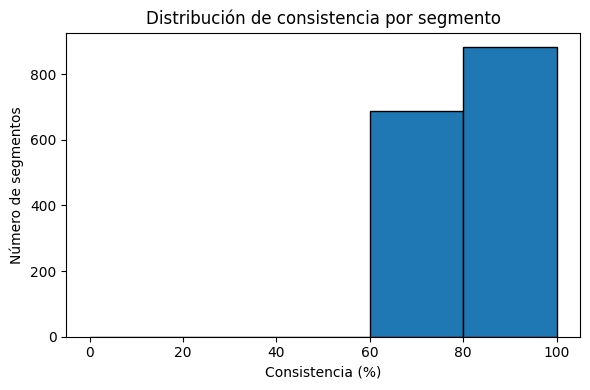


📊 Distribución de consistencia (%)
Consistencia_%
60.0     688
100.0    882
Name: count, dtype: int64

📌 Distribución de tipo modal
Tipo_modal
3     511
4    1059
Name: count, dtype: int64


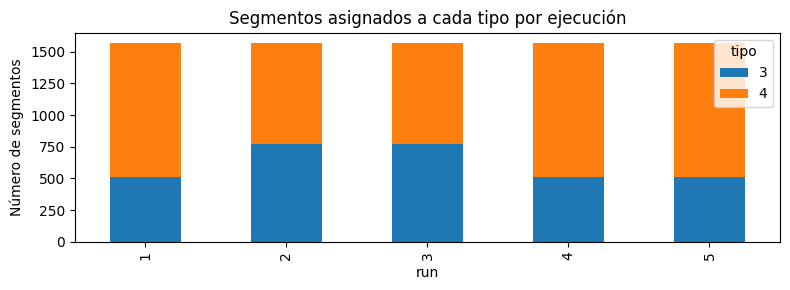


📁  Guardados: hist_consistencia_segmentos.png, stacked_bar_run_tipo.png, matriz_run_tipo.csv


In [30]:
# ============================================================
# 2. Cálculo de consistencia, histogramas y tablas globales
# ============================================================

# ---------- 2.1 Cargar archivos ----------
df_runs  = pd.read_csv("kmedoids_clusters_runs.csv")   # Segment_ID, cluster_run1..5
df_map   = pd.read_csv("cluster_tipo_mapping.csv")     # run, cluster, tipo

#  Diccionario (run, cluster) → tipo
map_dict = {(r, c): t for r, c, t in df_map.itertuples(index=False)}

# ---------- 2.2 Crear columnas tipo_run1..5 ----------
for run in range(1, 6):
    col_clu  = f"cluster_run{run}"
    col_tipo = f"tipo_run{run}"
    df_runs[col_tipo] = df_runs[col_clu].apply(
        lambda cid: map_dict.get((run, cid), -1)       # -1: tipo desconocido
    )

tipo_cols = [f"tipo_run{r}" for r in range(1, 6)]

# ---------- 2.3 Estadísticas por segmento ----------
def stats_row(row):
    tipos = [row[c] for c in tipo_cols]
    cnt   = Counter(tipos)
    tipo_modal, freq_modal = cnt.most_common(1)[0]
    consist_pct  = 100 * freq_modal / 5
    perfect      = freq_modal == 5
    sin_dom      = len(cnt) == 5                       # los 5 tipos distintos
    return pd.Series({
        "Tipo_modal": tipo_modal,
        "Frecuencia_tipo_modal": freq_modal,
        "Consistencia_%": consist_pct,
        "Perfectamente_consistente": perfect,
        "Sin_tipo_dominante": sin_dom,
        "Distribucion_tipos": dict(cnt)                # opcional: para inspección
    })

df_stats = df_runs.apply(stats_row, axis=1)
df_final = pd.concat([df_runs[["Segment_ID"] + tipo_cols], df_stats], axis=1)

df_final.to_csv("estadisticas_por_segmento.csv", index=False)
print("📁  Guardado: estadisticas_por_segmento.csv")

# ---------- 2.4 Estadísticas globales ----------
total_seg   = len(df_final)
n_perfect   = df_final["Perfectamente_consistente"].sum()
n_no_dom    = df_final["Sin_tipo_dominante"].sum()

print(f"\n🔢  Total de segmentos: {total_seg}")
print(f"✅  Perfectamente consistentes (100 %): {n_perfect}  ({n_perfect/total_seg:.1%})")
print(f"⚠️   Sin tipo dominante (5 tipos diferentes): {n_no_dom}  ({n_no_dom/total_seg:.1%})")

# Histograma de consistencia
plt.figure(figsize=(6,4))
plt.hist(df_final["Consistencia_%"], bins=[0,20,40,60,80,100], edgecolor="black")
plt.xlabel("Consistencia (%)")
plt.ylabel("Número de segmentos")
plt.title("Distribución de consistencia por segmento")
plt.tight_layout()
plt.savefig("hist_consistencia_segmentos.png")
plt.show()

# Tabla distribución de consistencia
cons_tab = df_final["Consistencia_%"].value_counts().sort_index()
cons_tab.to_csv("distribucion_consistencia.csv", header=["Segmentos"])
print("\n📊 Distribución de consistencia (%)")
print(cons_tab)

# Distribución de tipos modales
tipo_tab = df_final["Tipo_modal"].value_counts().sort_index()
tipo_tab.to_csv("distribucion_tipo_modal.csv", header=["Segmentos"])
print("\n📌 Distribución de tipo modal")
print(tipo_tab)

# ---------- 2.5 Matriz run × tipo ----------
melt = df_final.melt(id_vars="Segment_ID", value_vars=tipo_cols,
                     var_name="run", value_name="tipo")
melt["run"] = melt["run"].str.extract(r"(\d)").astype(int)

pivot = pd.pivot_table(melt, index="run", columns="tipo",
                       values="Segment_ID", aggfunc="count", fill_value=0)
pivot.to_csv("matriz_run_tipo.csv")

plt.figure(figsize=(8,3))
pivot.plot(kind="bar", stacked=True, ax=plt.gca())
plt.ylabel("Número de segmentos")
plt.title("Segmentos asignados a cada tipo por ejecución")
plt.tight_layout()
plt.savefig("stacked_bar_run_tipo.png")
plt.show()

print("\n📁  Guardados: hist_consistencia_segmentos.png, stacked_bar_run_tipo.png, matriz_run_tipo.csv")


In [31]:
df_final = pd.read_csv("estadisticas_por_segmento.csv")


Here some graphs regarding segment distribution are obtained.

<ipython-input-32-ea708f7bef70>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_counts.index, y=tipo_counts.values, palette="Set2")


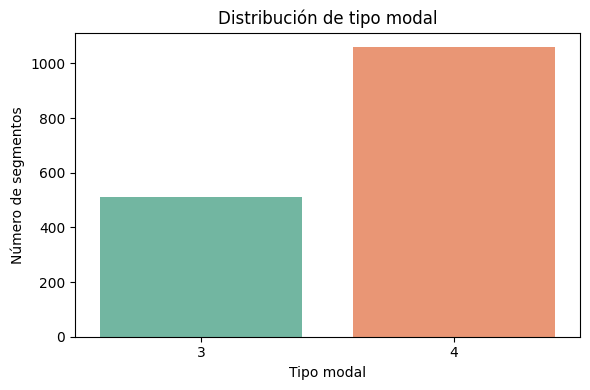

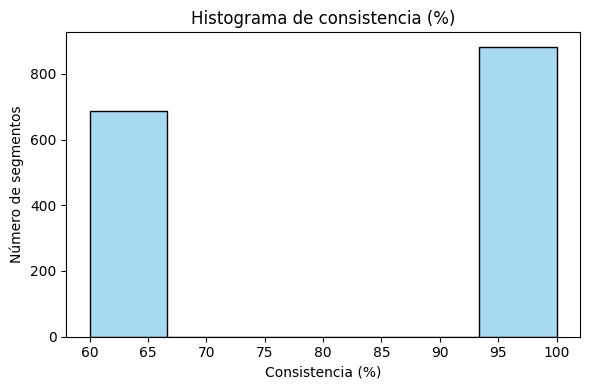

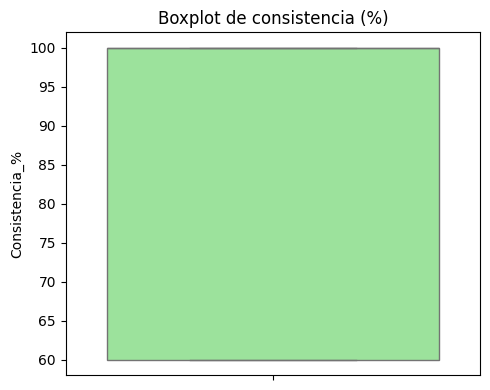

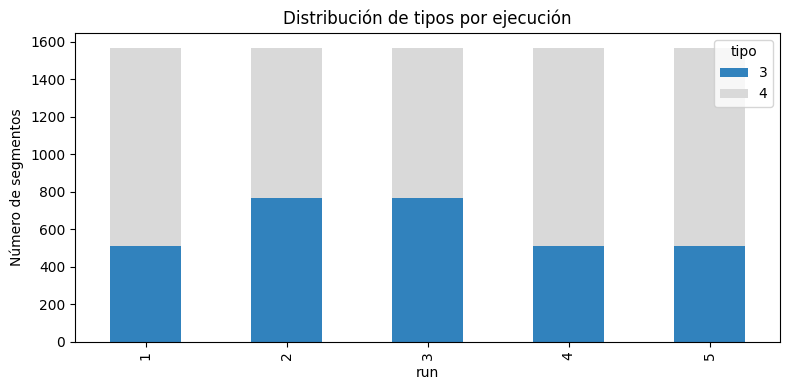

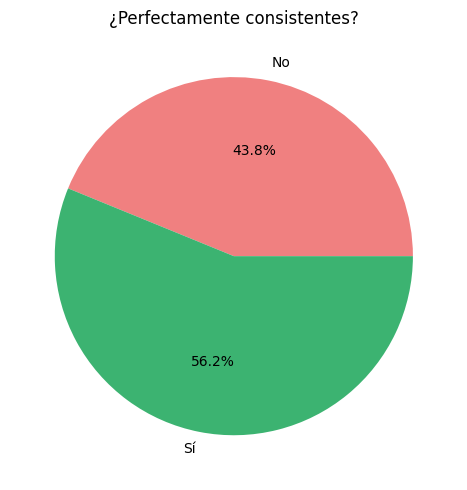

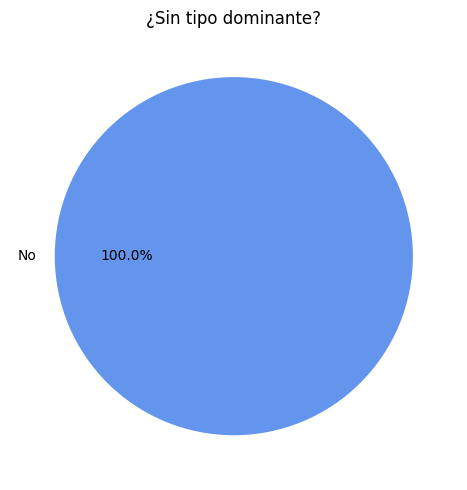

In [32]:
# 3. Tipo modal - gráfico de barras
tipo_counts = df_final["Tipo_modal"].value_counts().sort_index()
plt.figure(figsize=(6,4))
sns.barplot(x=tipo_counts.index, y=tipo_counts.values, palette="Set2")
plt.title("Distribución de tipo modal")
plt.xlabel("Tipo modal")
plt.ylabel("Número de segmentos")
plt.tight_layout()
plt.savefig("graf_tipo_modal.png")
plt.show()

# 6. Consistencia - histograma y boxplot
plt.figure(figsize=(6,4))
sns.histplot(df_final["Consistencia_%"], bins=6, kde=False, color="skyblue", edgecolor="black")
plt.title("Histograma de consistencia (%)")
plt.xlabel("Consistencia (%)")
plt.ylabel("Número de segmentos")
plt.tight_layout()
plt.savefig("graf_hist_consistencia.png")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=df_final["Consistencia_%"], color="lightgreen")
plt.title("Boxplot de consistencia (%)")
plt.tight_layout()
plt.savefig("graf_boxplot_consistencia.png")
plt.show()

# 7. Run × tipo - barras apiladas (ya lo tenías, pero mejorado)
df_melt = df_final.melt(id_vars="Segment_ID", value_vars=[f"tipo_run{i}" for i in range(1,6)],
                        var_name="run", value_name="tipo")
df_melt["run"] = df_melt["run"].str.extract("(\d)").astype(int)

pivot = pd.pivot_table(df_melt, index="run", columns="tipo", values="Segment_ID", aggfunc="count", fill_value=0)
pivot.plot(kind="bar", stacked=True, colormap="tab20c", figsize=(8,4))
plt.ylabel("Número de segmentos")
plt.title("Distribución de tipos por ejecución")
plt.tight_layout()
plt.savefig("graf_stacked_tipos_por_run.png")
plt.show()

# 8. Perfectamente consistentes - tarta
perfect_counts = df_final["Perfectamente_consistente"].value_counts().sort_index()
labels = ["No", "Sí"]
plt.figure(figsize=(5,5))
plt.pie(perfect_counts, labels=labels, autopct="%1.1f%%", colors=["lightcoral", "mediumseagreen"])
plt.title("¿Perfectamente consistentes?")
plt.tight_layout()
plt.savefig("graf_tarta_consistentes.png")
plt.show()

# 14. Sin tipo dominante - tarta
nodom_counts = df_final["Sin_tipo_dominante"].value_counts().sort_index()
labels_map = {0: "No", 1: "Sí", False: "No", True: "Sí"}
labels = [labels_map.get(k, str(k)) for k in nodom_counts.index]

plt.figure(figsize=(5,5))
plt.pie(nodom_counts, labels=labels, autopct="%1.1f%%", colors=["cornflowerblue", "orange"])
plt.title("¿Sin tipo dominante?")
plt.tight_layout()
plt.savefig("graf_tarta_sin_dominante.png")
plt.show()
